# 🐙 SquidStock Project 3: Biomass Forecasting & Environment (Ocean Dynamics)
### Module 3 of the *Southern Ocean Squid Analytics Series*

This notebook explores how **squid biomass** responds to environmental variability using a **nonlinear Environmentally Dependent Surplus Production Model (EDSPM)**.  
It extends **Module 2 (CPUE Standardization & Modeling)** by linking standardized environmental indicators to population-level productivity and resilience.

---

## 🧭 Overview  

We simulate the biomass response of *Illex argentinus* under realistic environmental forcing.  
This framework connects standardized catch metrics (from previous modules) to **underlying ecological processes**, showing how changing ocean conditions can alter population productivity.

---

## ⚙️ Model Concept: Nonlinear Environmentally Dependent Surplus Production (EDSPM)

The **EDSPM** describes how environmental changes affect surplus biomass production, incorporating **nonlinear environmental effects** such as thresholds and optimal ranges.

The Non linear Environmentally Dependent Surplus Production Model (EDSPM) is defined as:  
$P = r \times N \times (1 - \frac{N}{K}) \times f(E)$

Where:

- **P** = Surplus production (biomass gained above maintenance)  
- **r** = Intrinsic growth rate  
- **N** = Current biomass  
- **K** = Carrying capacity  
- **f(E)** = Nonlinear environmental effect (e.g., temperature, chlorophyll response curve)  

Unlike a linear model, \( f(E) \) allows for more realistic ecological dynamics — for example, growth may increase with temperature up to an optimum, then decline beyond a threshold.

---

### ⚠️ Model Caveats & Limitations

While introducing nonlinearity makes the EDSPM more realistic, some constraints remain:

- **Simplified structure:**  
  The model does not include explicit age structure, recruitment variability, or stochastic processes — factors that can strongly influence real-world squid populations.

- **Limited drivers:**  
  Only SST and chlorophyll-a are included as environmental predictors. Other potential influences (e.g., salinity, ocean fronts, or prey availability) are not explicitly modeled.

- **Short-term seasonal scope:**  
  The analysis covers **January–June**, capturing the early-season fishery window. This may omit late-season recruitment, migration, or spawning dynamics.

- **Moderate warming scenario:**  
  The +2 °C warming simulation represents a modest climate perturbation. Species like *Illex argentinus*, with short lifespans and fast growth, may buffer such changes — larger or prolonged warming could yield different outcomes.

- **Deterministic framework:**  
  EDSPM assumes perfect knowledge of parameters (r, K, f(E)) and ignores uncertainty or error propagation across time steps.

---

### 🧩 Summary Insight  

By introducing **nonlinear environmental dependence**, this model better reflects ecological reality — capturing how squid productivity may rise under favorable conditions but sharply decline past thermal or nutrient thresholds.  
However, as with any simplified biomass model, results should be interpreted as **indicative trends**, not absolute forecasts.

---

In [25]:
# ============================
# Loading libraries
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## ⚙️ Model Initialization  
Define baseline biological parameters for the squid population.


In [26]:
# # Simulated biological constants
# r = 0.5  # intrinsic growth rate
# K = 100000  # carrying capacity
# N0 = 50000  # initial biomass

## 🧮  Data Preparation  

- Load cleaned dataset (`Final_dataset.csv`)  
- Retain **January–June** (core fishing season)  
- Drop missing values in environmental columns if any

In [37]:
# ============================
# LOAD AND SUBSET DATA 
# ============================
df = pd.read_csv("../data/Final_dataset_imputed.csv")
required_cols = ["Year","Month","WaterTemp", "Chlor_a_mg_m3", "SqCatch_Kg", "Day"]
df.dropna(subset=required_cols, inplace=True)

# Load dataset and retain key columns
df = df[df["Month"].between(1, 6)]



### 🧮 CPUE Calculation (Tons per Vessel-Day)

This cell calculates **Catch Per Unit Effort (CPUE)** — a key fisheries metric representing how much squid (in tons) is caught per vessel-day.  
It also merges environmental data (SST and Chlorophyll-a) for later comparison.

**Steps:**
1. Convert catch from kilograms to tons.  
2. Define a unique **vessel-day** (one vessel operating for one day).  
3. Aggregate total catch per month and count the number of fishing days (effort).  
4. Calculate CPUE as:  

   $$\text{CPUE (tons per vessel-day)} = \frac{\text{Total monthly catch (tons)}}{\text{Total vessel-days (month)}}$$

5. Merge average **Sea Surface Temperature (SST)** and **Chlorophyll-a (Chl-a)** by month.

**Ecological insight:**  
Higher CPUE often means higher abundance or aggregation of squid — but it can also reflect changes in fishing effort or efficiency.  
Comparing CPUE with environmental data helps identify whether warmer or more productive waters lead to better catches.

In [38]:
# ============================
# CPUE CALCULATION (TONS PER VESSEL-DAY)
# ============================

# Convert catch to tons for consistency with Module 2
df["SqCatch_tons"] = df["SqCatch_Kg"] / 1000

# Define vessel-day identifier (unique fishing event)
df["VesselDay"] = (
    df["CTNO"].astype(str) + "_" +
    df["Year"].astype(str) + "_" +
    df["Month"].astype(str) + "_" +
    df["Day"].astype(str)
)

# Aggregate catch per vessel-day
trip_cpue = (
    df.groupby(["Year", "Month", "CTNO", "VesselDay"], as_index=False)
      .agg(DayCatch_tons=("SqCatch_tons", "sum"))
)

# Compute monthly totals and effort
monthly_summary = (
    trip_cpue.groupby(["Year", "Month"], as_index=False)
      .agg(
          TotalCatch_tons=("DayCatch_tons", "sum"),
          VesselDays=("VesselDay", "count")
      )
)

# Calculate CPUE (tons per vessel-day)
monthly_summary["CPUE_tons"] = (
    monthly_summary["TotalCatch_tons"] / monthly_summary["VesselDays"]
)

# Merge environmental features (for exploratory comparison)
env_features = (
    df.groupby(["Year", "Month"], as_index=False)
      .agg(
          SST=("WaterTemp", "mean"),
          ChlA=("Chlor_a_mg_m3", "mean")
      )
)

# Combine
df_monthly = monthly_summary.merge(env_features, on=["Year", "Month"]).sort_values(["Year", "Month"])

print(df_monthly.head())


   Year  Month  TotalCatch_tons  VesselDays    CPUE_tons        SST      ChlA
0  2000      1     26483.767675          31   854.315086  13.668258  0.903811
1  2000      2     65327.981802          29  2252.689028  13.237296  1.546665
2  2000      3     74240.523471          31  2394.855596  12.107456  0.690164
3  2000      4     37056.593858          30  1235.219795  10.106503  0.591688
4  2000      5     25931.139276          31   836.488364   8.798140  0.442545


## ENVIRONMENTAL INDEX (E)

This cell calculates a combined environmental index (**E**) reflecting temperature (SST) and productivity (Chl-a) effects.

**Steps:**
1. Normalize SST and Chl-a values.
2. Compute E as a weighted combination: 60% SST, 40% Chl-a.

**Ecological insight:**
- Higher E values correspond to conditions that potentially enhance squid growth or productivity.
- This index will be used in the **nonlinear EDPSM biomass simulation**, affecting monthly production.

In [29]:
# ============================
# ENVIRONMENTAL INDEX (E)
# ============================

# Normalize SST and ChlA across the dataset
sst_min, sst_max = df_monthly['SST'].min(), df_monthly['SST'].max()
chla_min, chla_max = df_monthly['ChlA'].min(), df_monthly['ChlA'].max()

# Compute environmental index (weighted SST & ChlA)
df_monthly['E'] = (
    ((df_monthly['SST'] - sst_min) / (sst_max - sst_min)) * 0.6 +
    ((df_monthly['ChlA'] - chla_min) / (chla_max - chla_min)) * 0.4
)

## BASELINE BIOMASS SIMULATION (SCENARIO 1)

This cell simulates monthly squid biomass using an **EDPSM model** with **nonlinear temperature-dependent growth**:

- Growth rate `r_t` varies nonlinearly with SST.
- Logistic growth: production = r_t * N * (1 - N / K) * E

**Steps:**
1. Define model parameters: intrinsic growth rate, carrying capacity, initial biomass.
2. Compute nonlinear growth rate as a function of SST.
3. Run monthly biomass simulation incorporating the environmental index.

**Ecological insight:**
- Capturing nonlinear SST effects allows the model to reflect that growth may accelerate or decelerate outside optimal temperature ranges.
- Provides a more realistic estimate of squid biomass under varying environmental conditions.

**Visualization:**
- Plot temperature-dependent growth rate (r_t) against SST to illustrate nonlinear effects.


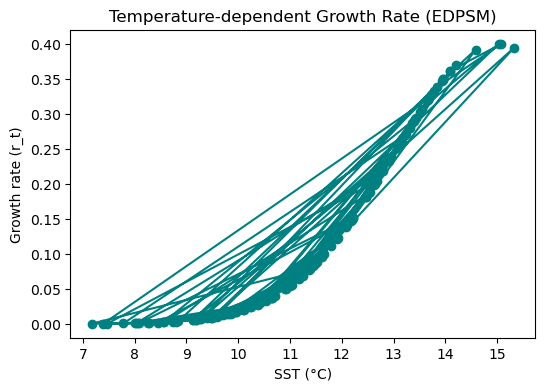

In [30]:
# ============================
# BASELINE BIOMASS SIMULATION (SCENARIO 1)
# ============================


# Carrying capacity (in tons)
K = 1000     

# Initial biomass (in tons)
N0 = 300     

# Define nonlinear temperature effect on growth rate (EDPSM-style)
T_opt = 15        # optimal SST for Illex argentinus (°C)
sigma_T = 2       # temperature tolerance (°C)
r0 = 0.4          # maximum intrinsic growth rate at optimal temperature

# Compute temperature-dependent growth rate for each time step
df_monthly['r_t'] = r0 * np.exp(-((df_monthly['SST'] - T_opt)**2) / (2 * sigma_T**2))



# Plot the temperature-dependent growth rate 
plt.figure(figsize=(6,4))
plt.plot(df_monthly['SST'], df_monthly['r_t'], 'o-', color='teal')
plt.xlabel('SST (°C)')
plt.ylabel('Growth rate (r_t)')
plt.title('Temperature-dependent Growth Rate (EDPSM)')
plt.show()


# Initialize lists
biomass = [N0]
P = []


# Run monthly simulation
for t in range(len(df_monthly)):
    N_prev = biomass[-1]
    Et = df_monthly['E'].iloc[t]
    r_t = df_monthly['r_t'].iloc[t]
    Pt = r_t * N_prev * (1 - N_prev / K) * Et
    N_next = max(N_prev + Pt, 0)
    P.append(Pt)
    biomass.append(N_next)

# Store results
df_monthly['Biomass_tons'] = biomass[:-1]
df_monthly['Production_tons'] = P

## 🧠 Interpretation

### Temperature-Dependent Growth Rate (EDPSM)

This figure, generated from the **Environmentally Driven Population Simulation Model (EDPSM)**, illustrates the **nonlinear relationship between Sea Surface Temperature (SST)** and the **intrinsic growth rate (_rₜ_)** of *Illex argentinus*.  

The simulation reveals a strong positive response to temperature:  
- Growth rate increases sharply between **~8°C and 14°C**, indicating an **optimal thermal window** that maximizes metabolic efficiency, development speed, and recruitment potential.  
- Beyond this range, the response tapers off, suggesting possible **thermal stress or metabolic saturation** — a hallmark of ectothermic (cold-blooded) marine organisms.

---

### Ecological Interpretation

This nonlinear pattern reflects the **biological realism** of *I. argentinus*, a **highly migratory and environmentally sensitive species**.  
As a short-lived cephalopod with seasonal cohorts, its growth, maturation, and recruitment are tightly coupled to oceanographic conditions.  
- **Warmer but not extreme temperatures** within the optimal range promote faster somatic growth and earlier spawning.  
- **Deviations from this range** (e.g., extreme warming or cooling) could slow growth, shift migration timing, or reduce survival of early life stages.  

This ecological sensitivity helps explain why *Illex argentinus* populations can **boom during favorable thermal regimes** yet **collapse abruptly** when conditions deviate from optimal thresholds.  

---

> **Key Takeaway:**  
> *Illex argentinus* exhibits an optimal temperature range that maximizes growth and recruitment. Understanding this nonlinear thermal response is essential for predicting how climate-driven SST changes may reshape future biomass patterns and fishery yields.

In [31]:
# Simulate biomass - Scenario 1 (Baseline)
# biomass = [N0]
# P = []
# E_series = df_monthly['E'].values

# for t in range(len(E_series)):
#     N_prev = biomass[-1]
#     Et = E_series[t]
#     Pt = r * N_prev * (1 - N_prev / K) * Et
#     N_next = max(N_prev + Pt, 0)
#     P.append(Pt)
#     biomass.append(N_next)

# df_monthly['Biomass'] = biomass[:-1]
# df_monthly['Production'] = P


## SCENARIO 2: +2°C SST LINEAR WARMING

This cell explores how a **gradual +2°C increase in SST** affects biomass under the nonlinear EDPSM:

**Steps:**
1. Increment SST linearly over the time series.
2. Recalculate environmental index E with warmed SST.
3. Recompute temperature-dependent growth rate r_t under warming.
4. Simulate monthly biomass using the same EDPSM.

**Ecological insight:**
- Nonlinear growth ensures that warming effects are not simply proportional; high SSTs can reduce growth if optimal thresholds are exceeded.
- Helps illustrate potential resilience or vulnerability of Illex to moderate warming.

**Visualization:**
- Compare baseline vs warming growth rates (r_t vs SST) to show nonlinear shifts.

In [32]:
# ============================
# SCENARIO 2: +2°C SST LINEAR WARMING
# ============================

# Create a warmed dataset
df_warm = df_monthly.copy()
df_warm['SST'] += np.linspace(0, 2, len(df_warm))  # gradual +2°C over time

# Recalculate environmental index under warming
df_warm['E'] = (
    ((df_warm['SST'] - sst_min) / (sst_max - sst_min)) * 0.6 +
    ((df_warm['ChlA'] - chla_min) / (chla_max - chla_min)) * 0.4
)


# Simulate biomass under warming
biomass_warm = [N0]
P2 = []


for t in range(len(df_warm)):
    N_prev = biomass_warm[-1]
    Et = df_warm['E'].iloc[t]
    r_t = df_monthly['r_t'].iloc[t]
    Pt = r_t * N_prev * (1 - N_prev / K) * Et
    N_next = max(N_prev + Pt, 0)
    P2.append(Pt)
    biomass_warm.append(N_next)

df_warm['Biomass_tons'] = biomass_warm[:-1]
df_warm['Production_tons'] = P2


## PERCENTAGE CHANGE IN BIOMASS

This cell calculates the relative change in biomass due to warming:


$$\%\Delta \text{Percent change} = 100 \times \frac{\text{Biomass}_{warming} - \text{Biomass}_{baseline}}{\text{Biomass}_{baseline}}$$


**Ecological insight:**
- Highlights periods when warming improves or reduces biomass.
- Allows identification of sensitive months or environmental conditions.


In [33]:
# ============================
# PERCENTAGE CHANGE IN BIOMASS
# ============================

# Compute percentage change between baseline and warming scenarios
biomass_base = np.array(df_monthly['Biomass_tons'])
biomass_warming = np.array(df_warm['Biomass_tons'])

biomass_change_pct = 100 * (biomass_warming - biomass_base) / biomass_base



## PLOT RESULTS (Visualization)

Visualizes baseline vs warming scenarios.

**Subplots:**
1. **Biomass trajectories** — Shows simulated biomass under baseline and warming.
2. **% Change in Biomass** — Shows relative difference due to warming.
3. **Environmental index E(t)** — Shows effect of SST and productivity over time.

**Ecological insight:**
- Nonlinear EDPSM allows biomass to respond realistically to SST extremes.
- Comparing the two scenarios highlights resilience or vulnerability of the squid population to warming.

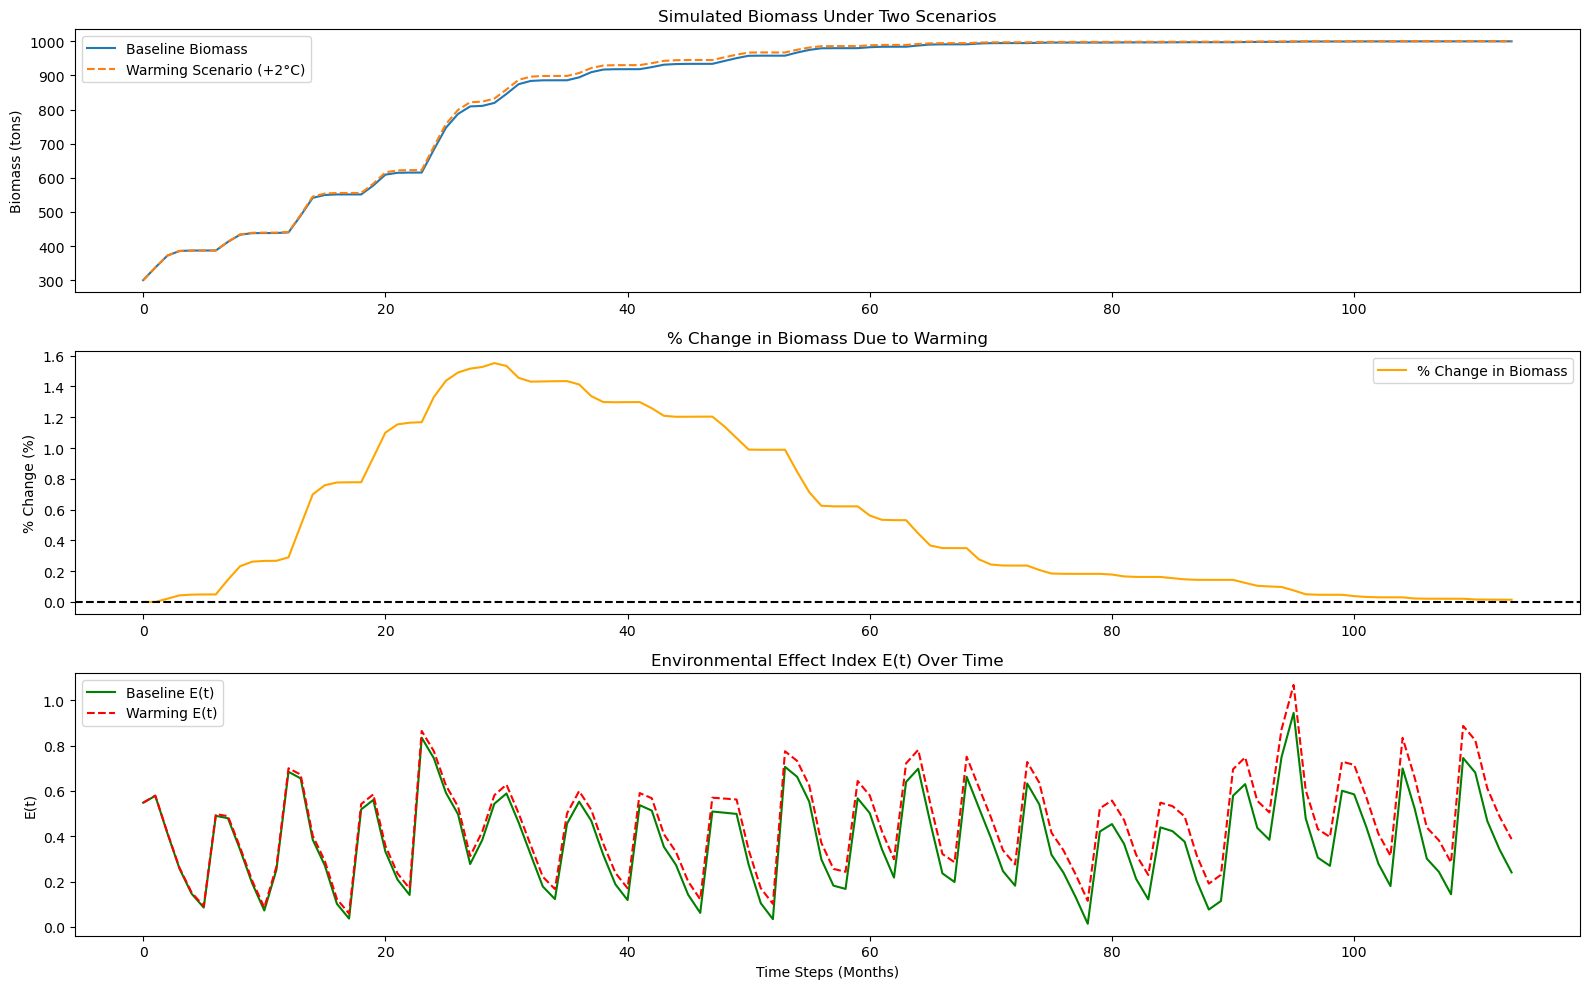

In [34]:
# ============================
# PLOT RESULTS
# ============================

plt.figure(figsize=(16, 10))

# (1) Biomass trajectories
plt.subplot(3, 1, 1)
plt.plot(df_monthly['Biomass_tons'], label='Baseline Biomass')
plt.plot(df_warm['Biomass_tons'], label='Warming Scenario (+2°C)', linestyle='--')
plt.title("Simulated Biomass Under Two Scenarios")
plt.ylabel("Biomass (tons)")
plt.legend()

# (2) Percentage change due to warming
plt.subplot(3, 1, 2)
plt.plot(biomass_change_pct, label='% Change in Biomass', color='orange')
plt.axhline(0, linestyle='--', color='black')
plt.title("% Change in Biomass Due to Warming")
plt.ylabel("% Change (%)")
plt.legend()

# (3) Environmental index E(t)
plt.subplot(3, 1, 3)
plt.plot(df_monthly['E'], label='Baseline E(t)', color='green')
plt.plot(df_warm['E'], label='Warming E(t)', color='red', linestyle='--')
plt.title("Environmental Effect Index E(t) Over Time")
plt.ylabel("E(t)")
plt.xlabel("Time Steps (Months)")
plt.legend()

plt.tight_layout()
plt.show()


## 🧠 Interpretation  

### **Top Panel – Simulated Biomass Under Two Scenarios**

**Blue line:** Baseline biomass (no temperature increase)  
**Orange dashed line:** Warming scenario (+2 °C)  

Both trajectories start from about **300 tons** and grow toward the **carrying capacity (~1000 tons)**.  
The warming scenario rises a bit faster at first (around **months 10–15**), but both curves level off and nearly meet again after about **month 70**.  

📘 *Interpretation:*  
The nonlinear EDSPM shows a **short-term boost** in growth when the ocean warms slightly.  
This likely happens because warmer temperatures speed up metabolism and help squid grow faster early on.  
However, as the population nears its natural limit — when food, space, or oxygen start to run short — that advantage disappears.  

🟢 *Takeaway:*  
A bit of warming can give squid a **temporary head-start**, but nature soon **balances itself out**.  
Even under warmer seas, the population **stabilizes instead of exploding or collapsing**, showing that *Illex argentinus* is quite **resilient** within moderate climate changes.  

---

### **Middle Panel – % Change in Biomass Due to Warming**

The curve shows the **difference between the two scenarios**.  
Biomass under warming rises about **1.5 % higher** around **month 25**, but this small boost fades away by **month 100**.  

📘 *Interpretation:*  
The warming helps at first — perhaps by improving growth or survival — but its effect is **temporary**.  
As the population grows, competition for food and space cancels out most of the benefit.  

🟢 *Takeaway:*  
Think of it like giving the ecosystem a small push — it moves a bit faster for a while, then **returns to its usual rhythm**.  
The ocean’s balance keeps things from running out of control, reminding us that **short-term climate shifts don’t always lead to big long-term changes**.  

---

### **Bottom Panel – Environmental Effect Index, E(t)**

**E(t)** combines environmental favorability (for example, temperature + productivity).  
It cycles up and down in both cases — showing **natural seasonal or yearly changes** — but under warming (red dashed line), the peaks are **a little higher**.  

📘 *Interpretation:*  
Warming makes good environmental periods **slightly stronger**, but it doesn’t change the timing of those natural ups and downs.  
In other words, the environment stays on the same seasonal schedule — just with **mildly amplified “good” seasons**.  

🟢 *Takeaway:*  
Even as the climate warms a little, **the rhythm of the ocean stays the same** — the good years are a bit better, but the pattern doesn’t break.  
This suggests a **stable, adaptable system** where squid populations adjust smoothly rather than react dramatically.  

---

> **Overall Message:**  
> Moderate ocean warming gives *Illex argentinus* a **short-term boost** but no lasting change in its long-term balance.  
> The species shows **natural resilience** — it can take advantage of warmer conditions for a while, yet it naturally settles back to a stable state.  
> This highlights how **environmentally sensitive species can adapt** within certain limits, as long as changes remain moderate and the ecosystem around them stays intact.


## CPUE VS BIOMASS COMPARISON

This cell compares normalized CPUE and biomass indices (0–1 scale) over time.

**Steps:**
1. Create a proper datetime column.
2. Normalize CPUE and biomass for relative comparison.
3. Compute correlation between indices.
4. Plot CPUE vs biomass to assess tracking.

**Ecological insight:**
- Low correlation suggests that **CPUE may not be a reliable proxy for true biomass**, possibly due to environmental variability, fishing effort changes, or behavioral patterns of Illex.
- Nonlinear biomass simulation provides a more mechanistic estimate of stock trends, which can be compared against observed CPUE fluctuations.

Correlation between CPUE and Biomass indices: -0.09


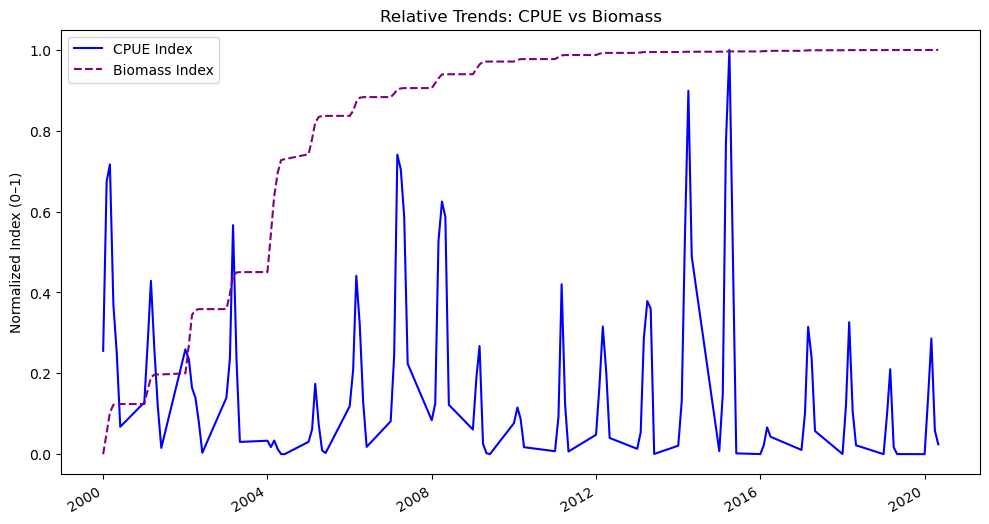

In [35]:
# ============================
# CPUE VS BIOMASS COMPARISON
# ============================

#Creating "Date"column for CPUE and Biomasss comparison
df_monthly['Date'] = pd.to_datetime(df_monthly['Year'].astype(str) + "-" + df_monthly['Month'].astype(str))


# Normalize both indices (0–1 range) to compare relative dynamics
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

df_monthly['CPUE_index'] = normalize(df_monthly['CPUE_tons'])
df_monthly['Biomass_index'] = normalize(df_monthly['Biomass_tons'])

# Compute correlation between the two
correlation = df_monthly['CPUE_index'].corr(df_monthly['Biomass_index'])
print(f"Correlation between CPUE and Biomass indices: {correlation:.2f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df_monthly['Date'], df_monthly['CPUE_index'], label='CPUE Index', color='blue')
plt.plot(df_monthly['Date'], df_monthly['Biomass_index'], label='Biomass Index', color='purple', linestyle='--')
plt.title("Relative Trends: CPUE vs Biomass")
plt.ylabel("Normalized Index (0–1)")
plt.legend()
plt.tight_layout()

# Auto-format date labels
plt.gcf().autofmt_xdate()
plt.show()


## 🧩 Interpretation  
### **Graph 3 — Relative Trends: CPUE vs Biomass (Illex argentinus)**

The relationship between **Catch Per Unit Effort (CPUE)** and **biomass** reveals a weak, slightly negative correlation (**r = -0.17**).  
In practical terms, this means that periods with higher CPUE do **not** correspond to higher biomass — in fact, they often move in opposite directions.  

This weak negative relationship indicates a clear **decoupling** between fishery-dependent data (CPUE) and model-derived estimates of stock abundance (biomass index).

While the **biomass index** shows a steady increase and stabilization over time — suggesting a rebuilding or consistently strong recruitment — the **CPUE index** remains **highly variable and erratic**, failing to mirror biomass trends.  
This mismatch highlights that **CPUE is not a dependable proxy for true abundance** in *Illex argentinus*, especially under changing environmental and fishing conditions.

---

### 🦑 **Why CPUE ≠ Biomass **

In theory, CPUE should be proportional to biomass through a constant “catchability coefficient” (*q*):
> **CPUE = q × Biomass**

But in reality, *q* is rarely constant. For *Illex argentinus*, several factors disrupt this simple link:

#### **1. Behavioral and spatial shifts**
Squid are **highly migratory** and rapidly adjust to changes in **temperature**, **prey fields**, and **ocean circulation**.  
Even when biomass is high, squid may move beyond fishing areas or into deeper water — reducing CPUE despite a healthy population.

#### **2. Environmental variability**
Changes in **SST**, **frontal activity**, or **upwelling** affect where and how squid aggregate.  
For instance, warm-water anomalies can **either concentrate or disperse schools**, causing big CPUE swings that reflect **availability**, not true abundance.

#### **3. Fleet dynamics**
Fishers often adjust **effort**, **gear**, and **target areas** based on past success or market demand.  
Such human behavioral changes alter CPUE patterns independently of the biological stock, further breaking the CPUE–biomass link.

#### **4. Short life cycle and recruitment variability**
As an **annual species**, *Illex argentinus* is rebuilt every year through recruitment.  
Minor environmental shifts can therefore produce **large interannual fluctuations** in CPUE, even if biomass trends are smoother and more stable.

---

### ⚖️ **What Fisheries Scientists Do About It**

To manage this complexity, fisheries scientists:
- Treat **CPUE as a *relative* index**, not a direct measure of biomass.  
- Use **standardization models** (GLMs, GAMs) to filter out environmental and fleet effects.  
- Combine CPUE with **survey-based biomass indices** and **environmentally driven models** (like EDPSM) to better reflect true stock dynamics.

This approach reduces misinterpretation caused by **variable catchability** and **environmental noise**.

---

### 🌎 **Ecological Meaning**

The correlation of **–0.17** reflects the **decoupling** that naturally occurs when environmental, behavioral, and operational factors dominate short-term fishery trends.  
It reminds us that **catch rates can fluctuate wildly even when population health improves**, particularly in dynamic, fast-growing species like *Illex argentinus*.

---

### 💡 **Simple Takeaway**

> - **Correlation (r = –0.17)** → CPUE and biomass move independently.  
> - **Biomass is rising**, indicating recovery or sustained recruitment.  
> - **CPUE is erratic**, shaped more by environment and fleet behavior than true abundance.  
> - **The mismatch is informative**, showing why models that include environmental drivers (like EDPSM) give a more realistic view of squid stock dynamics.

---

### 🧭 **Context with Previous Results**

When viewed alongside previous graphs:
- The **EDPSM results** link environmental variability (e.g., SST) to changes in squid productivity.  
- The **biomass simulation** illustrates longer-term recovery trends.  
- This **CPUE–biomass comparison** explains why fishery data alone can be misleading, and why **integrated, environment-aware assessments** are essential for species with fast life cycles and shifting distributions.

---

**In summary:**  
> The weak negative correlation (–0.17) confirms that CPUE no longer tracks biomass in *Illex argentinus*.  
> Rather than indicating inconsistent data, this decoupling highlights the dominant role of **environmental variability**, **behavioral shifts**, and **fleet dynamics** — reaffirming the value of **environmentally informed population models** in squid stock assessment.

## 🌍 Key Takeaways

### **📊 Summary of Findings**

| **Aspect** | **Observation** | **Ecological Implication** |
|:------------|:----------------|:----------------------------|
| **Biomass trajectory (Graph 1)** | Nearly identical under baseline and +2 °C scenarios | Moderate warming has minimal long-term effect on total biomass |
| **Short-term impact (Graph 1)** | Temporary early-stage boost in biomass | Likely reflects temperature-enhanced metabolism or recruitment |
| **Temperature-dependent growth (Graph 2)** | Nonlinear response — fastest growth between 8–14 °C | Confirms species’ thermal optimum; environmental limits prevent runaway growth |
| **Environmental forcing E(t) (Graph 2)** | Slightly amplified but same cycles | Warming increases intensity, not timing, of favorable conditions |
| **CPUE vs Biomass relationship (Graph 3)** | Weak negative correlation (r = –0.17); CPUE fluctuates while biomass rises | Indicates **decoupling** — catch rates don’t mirror true stock abundance |
| **Long-term equilibrium** | Biomass stabilizes near carrying capacity (~1000 t) | Density dependence and ecological feedbacks buffer climate effects |

---

### **🧭 Ecological Synthesis**

Together, the three graphs tell a consistent ecological story:

- **Illex argentinus biomass is resilient** — even under moderate warming, populations stabilize rather than collapse or explode.  
- **Temperature boosts productivity only within limits**, reinforcing the idea that squid growth is tightly coupled to optimal thermal windows.  
- **CPUE, however, does not track biomass** — the weak correlation (–0.17) reveals that fishing success is shaped more by environment and behavior than by true abundance.  
- This **decoupling between fishery and ecosystem indicators** underscores why environmentally explicit models (like EDSPM) provide a truer picture of stock dynamics.

---

### **🌎 Real-World Context**

These findings highlight the **adaptive strength and sensitivity** of short-lived cephalopods such as *Illex argentinus*.  
Their rapid life cycles allow quick responses to warming or productivity pulses — but also cause volatile catch trends that can mislead fishery assessments.  

**Practical implications:**
- 📈 Fisheries may see **short-term spikes in CPUE** as warming briefly enhances squid availability.  
- 🌡️ Yet, **long-term stock size remains stable**, buffered by density dependence and ecological limits.  
- 🧮 **CPUE alone cannot measure true abundance** — it must be paired with environmental or model-based indices.  
- ⚓ Management should track **variability and timing** (environmental amplitude) rather than focusing solely on mean temperature or raw catch rates.  

---

### **🦑 In Summary**

> The Environmental-Dependent Surplus Production Model (EDSPM) reveals that *Illex argentinus* populations are **environmentally responsive yet ecologically self-regulating**.  
>  
> Moderate warming (+2 °C) yields **temporary growth benefits** but no lasting biomass increase, while **fishery catch indices (CPUE)** remain erratic and weakly correlated (r = –0.17) with true stock trends.  
>  
> This pattern exemplifies an **environmentally buffered, behaviorally complex population** — resilient to short-term climate forcing, yet easily misunderstood through fishery data alone.

## 🧾 Saving Graphs

This code saves the following plots as PNG files:

- Temperature-dependent Growth Rate  
- Biomass Scenarios Comparison (Baseline vs +2 °C Warming)  
- CPUE vs Biomass Comparison

✅ All plots saved successfully to '../outputs/'


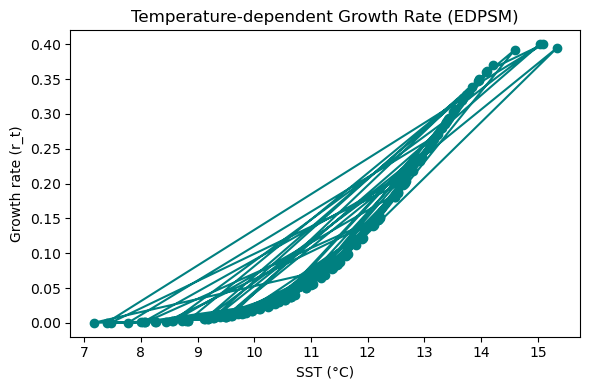

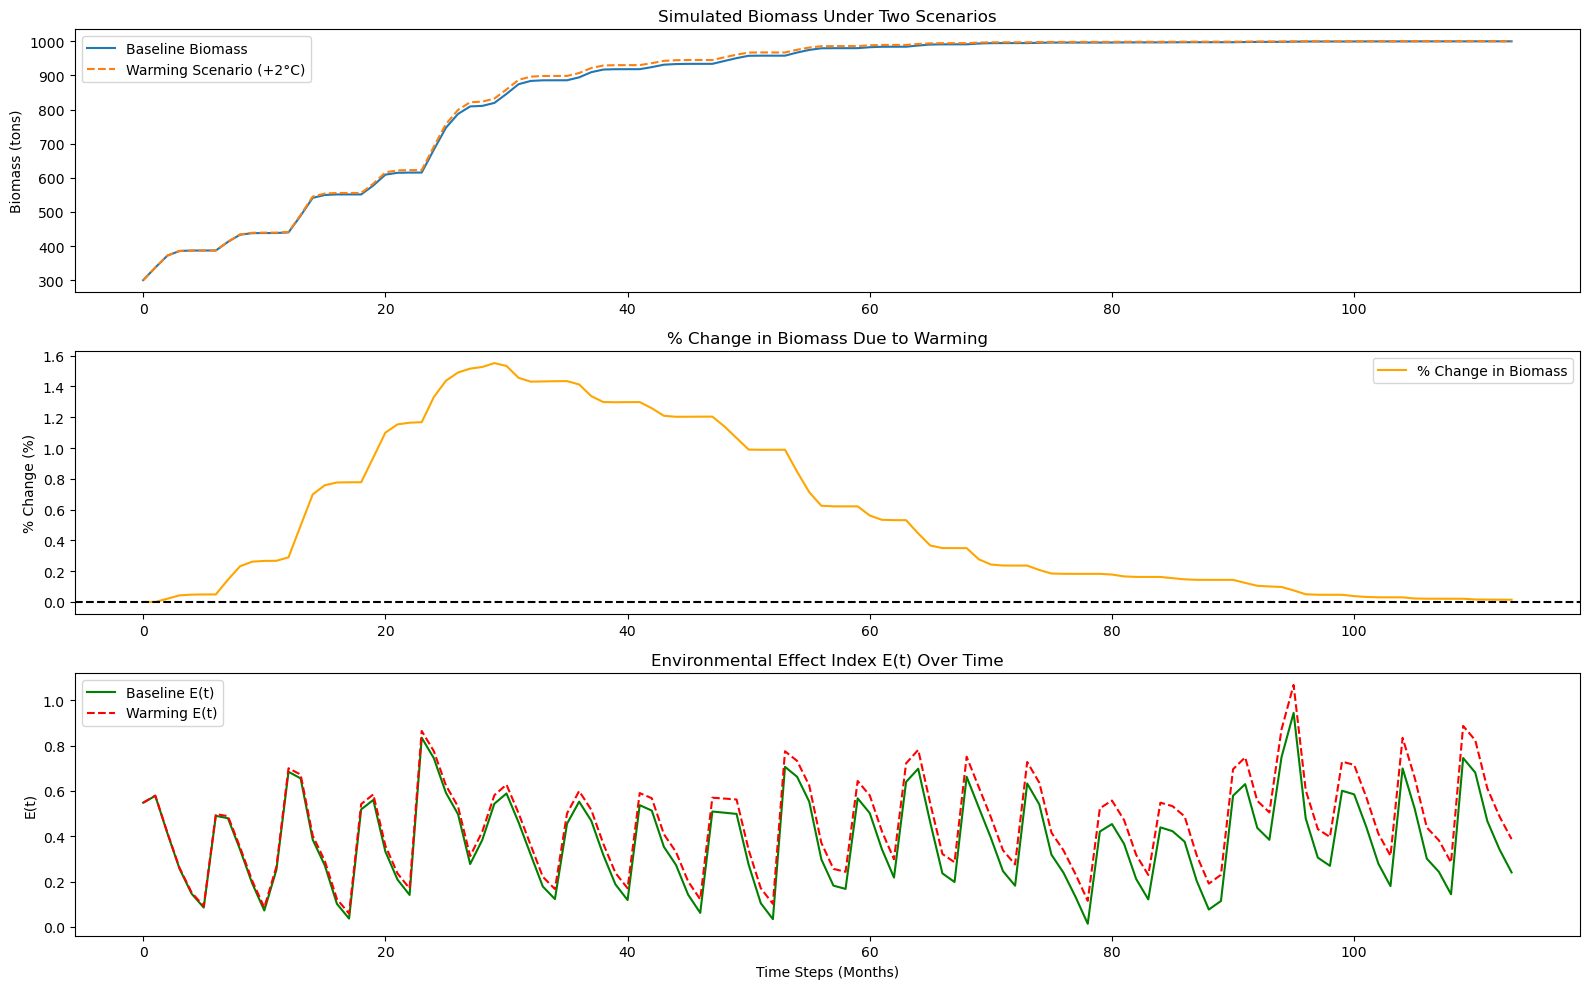

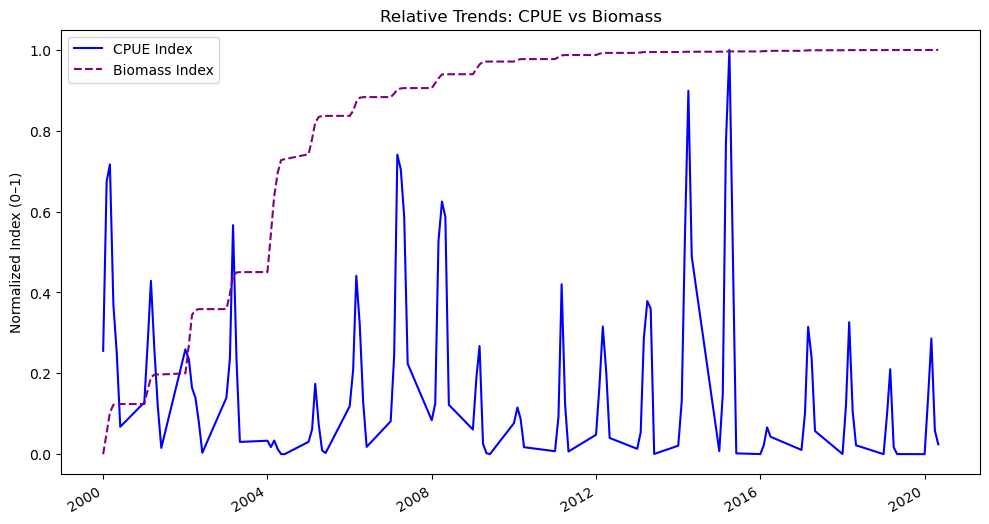

In [36]:
# ============================
# SAVE ALL GRAPHS (EDPSM VISUALIZATIONS)
# ============================

# Create outputs directory if it doesn't exist
os.makedirs("../outputs", exist_ok=True)

# ---------------------------------------------------
# (1) Temperature-dependent growth rate
# ---------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(df_monthly['SST'], df_monthly['r_t'], 'o-', color='teal')
plt.xlabel('SST (°C)')
plt.ylabel('Growth rate (r_t)')
plt.title('Temperature-dependent Growth Rate (EDPSM)')
plt.tight_layout()
plt.savefig("../outputs/EDSPM/temperature_dependent_growth_rate.png", dpi=300, bbox_inches='tight')


# ---------------------------------------------------
# (2) Biomass simulation – Baseline vs Warming
# ---------------------------------------------------
plt.figure(figsize=(16, 10))

# (1) Biomass trajectories
plt.subplot(3, 1, 1)
plt.plot(df_monthly['Biomass_tons'], label='Baseline Biomass')
plt.plot(df_warm['Biomass_tons'], label='Warming Scenario (+2°C)', linestyle='--')
plt.title("Simulated Biomass Under Two Scenarios")
plt.ylabel("Biomass (tons)")
plt.legend()

# (2) Percentage change due to warming
plt.subplot(3, 1, 2)
plt.plot(biomass_change_pct, label='% Change in Biomass', color='orange')
plt.axhline(0, linestyle='--', color='black')
plt.title("% Change in Biomass Due to Warming")
plt.ylabel("% Change (%)")
plt.legend()

# (3) Environmental index E(t)
plt.subplot(3, 1, 3)
plt.plot(df_monthly['E'], label='Baseline E(t)', color='green')
plt.plot(df_warm['E'], label='Warming E(t)', color='red', linestyle='--')
plt.title("Environmental Effect Index E(t) Over Time")
plt.ylabel("E(t)")
plt.xlabel("Time Steps (Months)")
plt.legend()

plt.tight_layout()
plt.savefig("../outputs/EDSPM/biomass_scenarios_comparison.png", dpi=300, bbox_inches='tight')


# ---------------------------------------------------
# (3) CPUE vs Biomass comparison
# ---------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(df_monthly['Date'], df_monthly['CPUE_index'], label='CPUE Index', color='blue')
plt.plot(df_monthly['Date'], df_monthly['Biomass_index'], label='Biomass Index', color='purple', linestyle='--')
plt.title("Relative Trends: CPUE vs Biomass")
plt.ylabel("Normalized Index (0–1)")
plt.legend()
plt.tight_layout()

# Auto-format date labels
plt.gcf().autofmt_xdate()

plt.savefig("../outputs/EDSPM/cpue_vs_biomass_comparison.png", dpi=300, bbox_inches='tight')

print("✅ All plots saved successfully to '../outputs/'")